# Experiment 9: Intra-Identity Embedding Variance Analysis

**Research Question:** Are per-identity retrieval failures caused by *rare identities*
(few training images) or by *visually ambiguous identities* (inconsistent appearance
across images of the same animal)? And does fine-tuning reduce intra-identity variance
more for hard identities than easy ones?

## Overview

1. **Data Loading**: Stratified train/validation split (same seed as all prior experiments)
2. **Backbone Loading**: Load frozen MegaDescriptor-L-384 and extract raw embeddings
3. **Model Training**: Train ArcFace projection head, save best checkpoint
4. **Reload Best Checkpoint**: Project val embeddings through the trained head
5. **Intra-Identity Variance**: Mean pairwise cosine distance within each identity cluster
6. **Per-Identity AP**: Compute AP for all 31 identities under both raw and fine-tuned models
7. **Variance vs AP Correlation**: Spearman correlation
8. **Variance Reduction**: How much does fine-tuning compress each identity cluster?
9. **Outlier Quadrant Analysis**: Four failure-mode categories
10. **Hard Pair Visualisation**: Most dissimilar image pairs within the same identity
11. **Surprising-Hard Diagnosis**: Tight-but-wrong clusters and their confusion partners

## Key Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **Intra-ID variance** | Mean pairwise cosine distance within identity | High = visually inconsistent |
| **Per-identity AP** | Average Precision for that identity's queries | Low = model fails this jaguar |
| **Variance reduction** | var_raw - var_finetuned | High = fine-tuning helped most |
| **Spearman rho** | Rank correlation: variance vs AP | Negative = variance predicts failure |

## Hypothesis
- High intra-identity variance predicts low AP
- Fine-tuning reduces variance more for high-variance identities
- Outliers (low variance + low AP) reveal identities confused with a specific other identity

## Controlled Variables (identical to all prior experiments)
- Backbone: MegaDescriptor-L-384 (frozen)
- Projection head: Linear(1536->512->256), BN, ReLU, Dropout(0.3)
- Loss: ArcFace (margin=0.5, scale=64)
- Optimizer: AdamW (lr=1e-4, weight_decay=1e-4)
- Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
- Epochs: 50, Batch: 32, Seed: 42

## 1. Setup and Configuration

In [1]:
import os
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import wandb
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
os.environ['HF_TOKEN']      = user_secrets.get_secret('hf_api')
os.environ['WANDB_API_KEY'] = user_secrets.get_secret('wandb_api')

RANDOM_SEED = 42

def set_seed(seed):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device:  {device}')
print(f'PyTorch: {torch.__version__}  |  timm: {timm.__version__}')

Device:  cuda
PyTorch: 2.9.0+cu126  |  timm: 1.0.24


In [2]:
RANDOM_SEED = 42

config = {
    'data_dir':       Path('/kaggle/input/competitions/jaguar-re-id'),
    'checkpoint_dir': Path('/kaggle/working/checkpoints'),
    'cache_dir':      Path('/kaggle/working/embeddings'),
    'megadescriptor_model': 'hf-hub:BVRA/MegaDescriptor-L-384',
    'input_size':     384,
    'embedding_dim':  256,
    'hidden_dim':     512,
    'dropout':        0.3,
    'arcface_margin': 0.5,
    'arcface_scale':  64.0,
    'batch_size':     32,
    'learning_rate':  1e-4,
    'weight_decay':   1e-4,
    'num_epochs':     50,
    'patience':       10,
    'val_split':      0.2,
    'seed':           RANDOM_SEED,
}

config['checkpoint_dir'].mkdir(parents=True, exist_ok=True)
config['cache_dir'].mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = config['checkpoint_dir'] / 'variance_arcface_best.pth'

print('Experiment 9 Configuration:')
print(f"  Backbone:       {config['megadescriptor_model']}")
print(f"  Embedding dim:  {config['embedding_dim']}")
print(f"  ArcFace:        margin={config['arcface_margin']}, scale={config['arcface_scale']}")
print(f"  Training:       {config['num_epochs']} epochs, bs={config['batch_size']}, patience={config['patience']}")
print(f"  Checkpoint:     {CHECKPOINT_PATH}")

Experiment 9 Configuration:
  Backbone:       hf-hub:BVRA/MegaDescriptor-L-384
  Embedding dim:  256
  ArcFace:        margin=0.5, scale=64.0
  Training:       50 epochs, bs=32, patience=10
  Checkpoint:     /kaggle/working/checkpoints/variance_arcface_best.pth


In [3]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: pranav-birari (pranav-birari-university-of-potsdam) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [4]:
wandb.init(
    project=os.getenv('WANDB_PROJECT', 'jaguar-reid-iota'),
    config={
        'experiment':     'intra-identity-variance',
        'backbone':       config['megadescriptor_model'],
        'embedding_dim':  config['embedding_dim'],
        'hidden_dim':     config['hidden_dim'],
        'dropout':        config['dropout'],
        'arcface_margin': config['arcface_margin'],
        'arcface_scale':  config['arcface_scale'],
        'batch_size':     config['batch_size'],
        'learning_rate':  config['learning_rate'],
        'weight_decay':   config['weight_decay'],
        'num_epochs':     config['num_epochs'],
        'patience':       config['patience'],
        'val_split':      config['val_split'],
        'seed':           config['seed'],
    },
    name='intra-identity-variance',
)
print('W&B run initialised: intra-identity-variance')
print('  training/     -> epoch metrics')
print('  variance/     -> per-identity variance metrics')
print('  correlation/  -> variance vs AP scatter plots')
print('  hard_pairs/   -> most dissimilar same-identity image pairs')
print('  per_identity/ -> summary table')

W&B run initialised: intra-identity-variance
  training/     -> epoch metrics
  variance/     -> per-identity variance metrics
  correlation/  -> variance vs AP scatter plots
  hard_pairs/   -> most dissimilar same-identity image pairs
  per_identity/ -> summary table


## 2. Load and Prepare Data

In [5]:
train_df = pd.read_csv(config['data_dir'] / 'train.csv')
print(f'Total images: {len(train_df)}  |  Identities: {train_df["ground_truth"].nunique()}')
print(train_df.head())
ic = train_df['ground_truth'].value_counts()
print(f'Min: {ic.min()} ({ic.idxmin()})  Max: {ic.max()} ({ic.idxmax()})  Mean: {ic.mean():.1f}')

Total images: 1895  |  Identities: 31
         filename ground_truth
0  train_0001.png        Abril
1  train_0002.png        Abril
2  train_0003.png        Abril
3  train_0004.png       Akaloi
4  train_0005.png       Akaloi
Min: 13 (Ipepo)  Max: 183 (Marcela)  Mean: 61.1


In [6]:
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

train_data, val_data = train_test_split(
    train_df, test_size=config['val_split'],
    random_state=config['seed'], stratify=train_df['ground_truth'])

assert set(train_data['ground_truth'].unique()) == set(val_data['ground_truth'].unique())
print(f'Train: {len(train_data)}  Val: {len(val_data)}  Identities: {num_classes}')
print('All identities present in both sets')

train_labels_enc = train_data['label_encoded'].values
val_labels_enc   = label_encoder.transform(val_data['ground_truth'].values)
val_labels_str   = val_data['ground_truth'].values

train_paths = [config['data_dir']/'train/train'/fn for fn in train_data['filename'].astype(str)]
val_paths   = [config['data_dir']/'train/train'/fn for fn in val_data['filename'].astype(str)]

val_counts = dict(zip(*np.unique(val_labels_str, return_counts=True)))

wandb.log({'num_identities': num_classes,
           'train_samples': len(train_data), 'val_samples': len(val_data)})

Train: 1516  Val: 379  Identities: 31
All identities present in both sets


## 3. Load MegaDescriptor Backbone and Extract Embeddings

In [7]:
print('Loading MegaDescriptor-L-384...')
backbone = timm.create_model(
    config['megadescriptor_model'], pretrained=True,
    num_classes=0, img_size=config['input_size'])
backbone.eval()
for p in backbone.parameters(): p.requires_grad = False
backbone.to(device)

preprocess = transforms.Compose([
    transforms.Resize((config['input_size'], config['input_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

with torch.no_grad():
    dummy = torch.randn(1, 3, config['input_size'], config['input_size']).to(device)
    backbone_dim = backbone(dummy).shape[1]
print(f'  Backbone dim: {backbone_dim}  |  Params: {sum(p.numel() for p in backbone.parameters()):,}  |  Frozen: True')

Loading MegaDescriptor-L-384...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

  Backbone dim: 1536  |  Params: 195,198,516  |  Frozen: True


In [8]:
@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc='Extracting'):
    model.eval(); all_embs = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        paths = image_paths[i:i+batch_size]; tensors = []
        for p in paths:
            try:    tensors.append(preprocess(Image.open(p).convert('RGB')))
            except: tensors.append(torch.zeros(3, config['input_size'], config['input_size']))
        all_embs.append(model(torch.stack(tensors).to(device)).cpu().numpy())
    return np.vstack(all_embs)


tr_cache = config['cache_dir'] / 'megadesc_train_embeddings.npz'
if tr_cache.exists():
    train_embeddings = np.load(tr_cache)['embeddings']
    print(f'Loaded cached train embeddings: {train_embeddings.shape}')
else:
    train_embeddings = extract_embeddings(backbone, train_paths, config['batch_size'], 'Train')
    np.savez_compressed(tr_cache, embeddings=train_embeddings)
    print(f'Extracted + cached: {train_embeddings.shape}')

va_cache = config['cache_dir'] / 'megadesc_val_embeddings.npz'
if va_cache.exists():
    val_embeddings = np.load(va_cache)['embeddings']
    print(f'Loaded cached val embeddings:   {val_embeddings.shape}')
else:
    val_embeddings = extract_embeddings(backbone, val_paths, config['batch_size'], 'Val')
    np.savez_compressed(va_cache, embeddings=val_embeddings)
    print(f'Extracted + cached: {val_embeddings.shape}')

# L2-normalise raw embeddings for cosine similarity
raw_embs_n = val_embeddings / (np.linalg.norm(val_embeddings, axis=1, keepdims=True) + 1e-12)
print(f'Raw val embeddings L2-normalised: {raw_embs_n.shape}')

Train:   0%|          | 0/48 [00:00<?, ?it/s]

Extracted + cached: (1516, 1536)


Val:   0%|          | 0/12 [00:00<?, ?it/s]

Extracted + cached: (379, 1536)
Raw val embeddings L2-normalised: (379, 1536)


## 4. Model Architecture

In [9]:
class EmbeddingProjection(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim), nn.BatchNorm1d(output_dim),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None: nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
    def forward(self, x): return self.net(x)


class ArcFaceHead(nn.Module):
    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.scale = scale
        self.cos_m = math.cos(margin); self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, emb, labels):
        emb_n = F.normalize(emb, p=2, dim=1)
        w_n   = F.normalize(self.weight, p=2, dim=1)
        cos   = torch.clamp(F.linear(emb_n, w_n), -1.0, 1.0)
        sin   = torch.sqrt(1.0 - cos**2)
        phi   = cos * self.cos_m - sin * self.sin_m
        phi   = torch.where(cos > self.th, phi, cos - self.mm)
        oh    = torch.zeros_like(cos).scatter_(1, labels.view(-1,1).long(), 1.0)
        return (oh * phi + (1 - oh) * cos) * self.scale


class ArcFaceModel(nn.Module):
    def __init__(self, input_dim, num_classes, embedding_dim=256,
                 hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.projection = EmbeddingProjection(input_dim, hidden_dim, embedding_dim, dropout)
        self.arcface    = ArcFaceHead(embedding_dim, num_classes, margin, scale)

    def forward(self, x, labels):
        emb = self.projection(x)
        return self.arcface(emb, labels), emb

    def get_embeddings(self, x):
        return self.projection(x)


_m = ArcFaceModel(backbone_dim, num_classes).to(device)
_l, _e = _m(torch.randn(4, backbone_dim).to(device), torch.zeros(4, dtype=torch.long).to(device))
print(f'Model sanity check: logits={_l.shape}, emb={_e.shape}')
print(f'  Trainable params: {sum(p.numel() for p in _m.parameters() if p.requires_grad):,}')
del _m, _l, _e

Model sanity check: logits=torch.Size([4, 31]), emb=torch.Size([4, 256])
  Trainable params: 927,744


## 5. Training Setup

In [10]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels     = torch.LongTensor(labels)
    def __len__(self):          return len(self.labels)
    def __getitem__(self, idx): return self.embeddings[idx], self.labels[idx]


def _map_from_embeddings(emb, labels):
    emb = emb / (np.linalg.norm(emb, axis=1, keepdims=True) + 1e-12)
    sim = emb @ emb.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql = labels[q]; is_match = (labels==ql).astype(int); is_match[q]=0
        n_pos = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec*sm)/n_pos))
    return float(np.mean([np.mean(v) for v in id_aps.values()]))


def compute_validation_map(model, val_embs, val_labels):
    model.eval()
    with torch.no_grad():
        emb = model.get_embeddings(torch.FloatTensor(val_embs).to(device)).cpu().numpy()
    return _map_from_embeddings(emb, val_labels)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train(); total_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc='Train', leave=False)
    for emb, labels in pbar:
        emb, labels = emb.to(device), labels.to(device)
        logits, _   = model(emb, labels); loss = criterion(logits, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}', acc=f'{100.*correct/total:.1f}%')
    return total_loss / len(loader), 100. * correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval(); total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for emb, labels in tqdm(loader, desc='Val', leave=False):
            emb, labels = emb.to(device), labels.to(device)
            logits, _   = model(emb, labels); loss = criterion(logits, labels)
            total_loss += loss.item()
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / len(loader), 100. * correct / total


train_loader = DataLoader(EmbeddingDataset(train_embeddings, train_labels_enc),
                           batch_size=config['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(EmbeddingDataset(val_embeddings,   val_labels_enc),
                           batch_size=config['batch_size'], shuffle=False, num_workers=0)

print(f'Train loader: {len(train_loader)} batches  |  Val loader: {len(val_loader)} batches')

Train loader: 48 batches  |  Val loader: 12 batches


## 6. Training Loop

In [11]:
set_seed(config['seed'])

model = ArcFaceModel(
    backbone_dim, num_classes, config['embedding_dim'], config['hidden_dim'],
    config['arcface_margin'], config['arcface_scale'], config['dropout']).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(),
                               lr=config['learning_rate'], weight_decay=config['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5)

history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc','val_map','lr']}
best_map = 0.0; best_epoch = 0; patience_counter = 0

for epoch in range(1, config['num_epochs'] + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss,   val_acc   = validate_epoch(model, val_loader, criterion, device)
    val_map               = compute_validation_map(model, val_embeddings, val_labels_str)
    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]['lr']

    for k, v in zip(['train_loss','train_acc','val_loss','val_acc','val_map','lr'],
                    [train_loss, train_acc, val_loss, val_acc, val_map, lr]):
        history[k].append(v)

    wandb.log({'training/epoch': epoch, 'training/train_loss': train_loss,
               'training/train_acc': train_acc, 'training/val_loss': val_loss,
               'training/val_acc': val_acc, 'training/val_map': val_map, 'training/lr': lr})

    improved = ''
    if val_map > best_map:
        best_map = val_map; best_epoch = epoch; patience_counter = 0
        torch.save({'epoch': epoch, 'model_state_dict': model.state_dict(),
                    'val_map': val_map, 'val_loss': val_loss,
                    'megadescriptor_dim': backbone_dim, 'num_classes': num_classes},
                   CHECKPOINT_PATH)
        improved = f'  Saved (epoch {epoch}, mAP={val_map:.4f})'
    else:
        patience_counter += 1

    print(f'  Epoch {epoch:3d}/{config["num_epochs"]} | '
          f'TrLoss:{train_loss:.4f} TrAcc:{train_acc:.1f}% | '
          f'VaLoss:{val_loss:.4f} VaAcc:{val_acc:.1f}% VamAP:{val_map:.4f} | '
          f'LR:{lr:.2e}{improved}')
    if patience_counter >= config['patience']:
        print(f'\nEarly stopping at epoch {epoch}'); break

print(f'\nTraining complete.  Best val mAP: {best_map:.4f} @ epoch {best_epoch}')

Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch   1/50 | TrLoss:36.5123 TrAcc:0.0% | VaLoss:31.5810 VaAcc:0.0% VamAP:0.3339 | LR:1.00e-04  Saved (epoch 1, mAP=0.3339)


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

...

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  49/50 | TrLoss:0.8027 TrAcc:87.7% | VaLoss:4.7294 VaAcc:82.6% VamAP:0.7737 | LR:1.00e-04


Train:   0%|          | 0/48 [00:00<?, ?it/s]

Val:   0%|          | 0/12 [00:00<?, ?it/s]

  Epoch  50/50 | TrLoss:0.7703 TrAcc:87.8% | VaLoss:4.6852 VaAcc:83.6% VamAP:0.7748 | LR:1.00e-04

Training complete.  Best val mAP: 0.7755 @ epoch 48


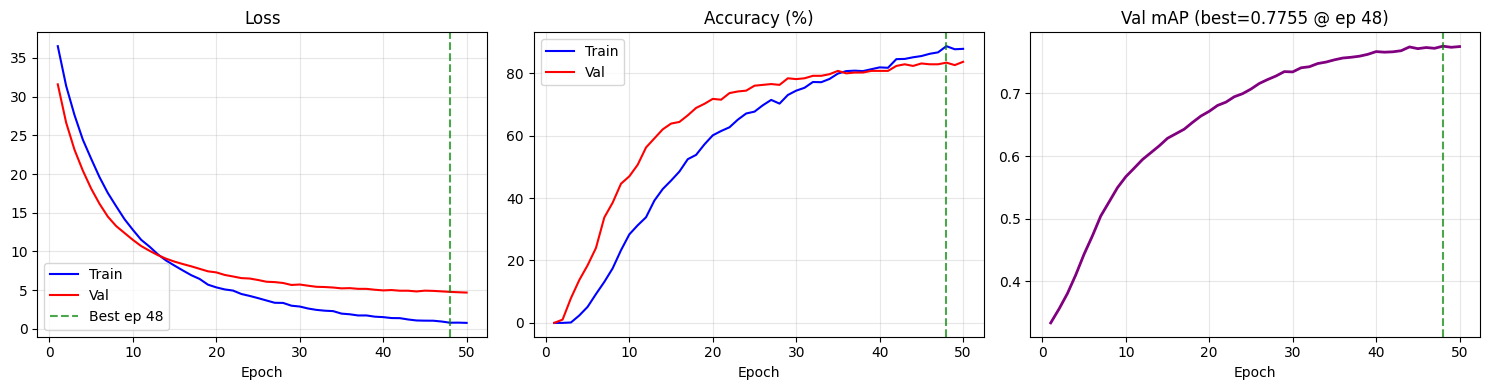

In [12]:
epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'],   'r-', label='Val')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ep {best_epoch}')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'],   'r-', label='Val')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_map'], color='purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_title(f'Val mAP (best={best_map:.4f} @ ep {best_epoch})')
axes[2].grid(True, alpha=0.3)

for ax in axes: ax.set_xlabel('Epoch')
plt.tight_layout()
wandb.log({'training/curves': wandb.Image(fig)})
plt.savefig(config['checkpoint_dir']/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Reload Best Checkpoint and Project Val Embeddings

We reload the best checkpoint and project the cached val embeddings through the trained head.
We then have two sets of L2-normalised val embeddings to compare:
- **`raw_embs_n`** — straight out of MegaDescriptor, no fine-tuning
- **`ft_embs_n`**  — projected through the best ArcFace head

In [13]:
print(f'Reloading best checkpoint from {CHECKPOINT_PATH}...')
ckpt = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

head = ArcFaceModel(
    ckpt['megadescriptor_dim'], ckpt['num_classes'],
    config['embedding_dim'], config['hidden_dim'],
    config['arcface_margin'], config['arcface_scale'], config['dropout']).to(device)
head.load_state_dict(ckpt['model_state_dict'])
head.eval()
for p in head.parameters(): p.requires_grad = False

print(f"  Epoch:   {ckpt['epoch']}")
print(f"  Val mAP: {ckpt['val_map']:.4f}")
print(f'  Frozen:  True')

with torch.no_grad():
    ft_embs = head.get_embeddings(
        torch.FloatTensor(val_embeddings).to(device)).cpu().numpy()

ft_embs_n = ft_embs / (np.linalg.norm(ft_embs, axis=1, keepdims=True) + 1e-12)

_v = _map_from_embeddings(ft_embs_n, val_labels_str)
assert abs(_v - ckpt['val_map']) < 0.002, f'mAP mismatch: {_v:.4f} vs {ckpt["val_map"]:.4f}'
print(f'  Verified reloaded mAP: {_v:.4f}')
print(f'Fine-tuned val embeddings: {ft_embs_n.shape}')

wandb.log({'checkpoint/epoch': ckpt['epoch'], 'checkpoint/val_map': ckpt['val_map']})

Reloading best checkpoint from /kaggle/working/checkpoints/variance_arcface_best.pth...
  Epoch:   48
  Val mAP: 0.7755
  Frozen:  True
  Verified reloaded mAP: 0.7755
Fine-tuned val embeddings: (379, 256)


## 8. Intra-Identity Variance

For each identity, compute the **mean pairwise cosine distance** within its val cluster:

```
variance(i) = mean over all pairs (a,b) in identity i of: 1 - cos_sim(emb_a, emb_b)
```

Computed for both raw MegaDescriptor and fine-tuned embeddings so we can measure
how much training compresses (or expands) each identity cluster.

In [14]:
def intra_identity_variance(embs_n, labels):
    variances = {}
    for identity in np.unique(labels):
        mask = labels == identity
        vecs = embs_n[mask]
        if len(vecs) < 2:
            variances[identity] = 0.0; continue
        sim_matrix  = vecs @ vecs.T
        triu_idx    = np.triu_indices(len(vecs), k=1)
        pairwise_sim = sim_matrix[triu_idx]
        variances[identity] = float(np.mean(1.0 - pairwise_sim))
    return variances


def per_identity_ap(embs_n, labels):
    sim = embs_n @ embs_n.T; np.fill_diagonal(sim, -1)
    id_aps = defaultdict(list)
    for q in range(len(labels)):
        ql = labels[q]; is_match = (labels==ql).astype(int); is_match[q]=0
        n_pos = is_match.sum()
        if n_pos == 0: continue
        order = np.argsort(-sim[q]); sm = is_match[order]
        cum = np.cumsum(sm); prec = cum / np.arange(1, len(sm)+1)
        id_aps[ql].append(float(np.sum(prec*sm)/n_pos))
    return {k: float(np.mean(v)) for k,v in id_aps.items()}


var_raw = intra_identity_variance(raw_embs_n, val_labels_str)
var_ft  = intra_identity_variance(ft_embs_n,  val_labels_str)
ap_raw  = per_identity_ap(raw_embs_n, val_labels_str)
ap_ft   = per_identity_ap(ft_embs_n,  val_labels_str)

identities   = sorted(var_raw.keys())
var_raw_vals = np.array([var_raw[i] for i in identities])
var_ft_vals  = np.array([var_ft[i]  for i in identities])
var_reduction = var_raw_vals - var_ft_vals
ap_raw_vals  = np.array([ap_raw[i]  for i in identities])
ap_ft_vals   = np.array([ap_ft[i]   for i in identities])
map_raw = float(np.mean(ap_raw_vals))
map_ft  = float(np.mean(ap_ft_vals))

print('Intra-identity variance (mean pairwise cosine distance):')
print(f'  Raw:        mean={var_raw_vals.mean():.4f}  min={var_raw_vals.min():.4f}  max={var_raw_vals.max():.4f}')
print(f'  Fine-tuned: mean={var_ft_vals.mean():.4f}  min={var_ft_vals.min():.4f}  max={var_ft_vals.max():.4f}')
print(f'  Mean variance reduction: {var_reduction.mean():.4f}')
print(f'  Identities where fine-tuning expanded variance: {(var_reduction < 0).sum()}/{len(identities)}')
print(f'\nOverall mAP: Raw={map_raw:.4f}  Fine-tuned={map_ft:.4f}  Delta={map_ft-map_raw:+.4f}')

Intra-identity variance (mean pairwise cosine distance):
  Raw:        mean=0.6521  min=0.2374  max=0.9030
  Fine-tuned: mean=0.4673  min=0.1275  max=0.9716
  Mean variance reduction: 0.1847
  Identities where fine-tuning expanded variance: 4/31

Overall mAP: Raw=0.3531  Fine-tuned=0.7755  Delta=+0.4224


## 9. Variance Distribution and Ranking

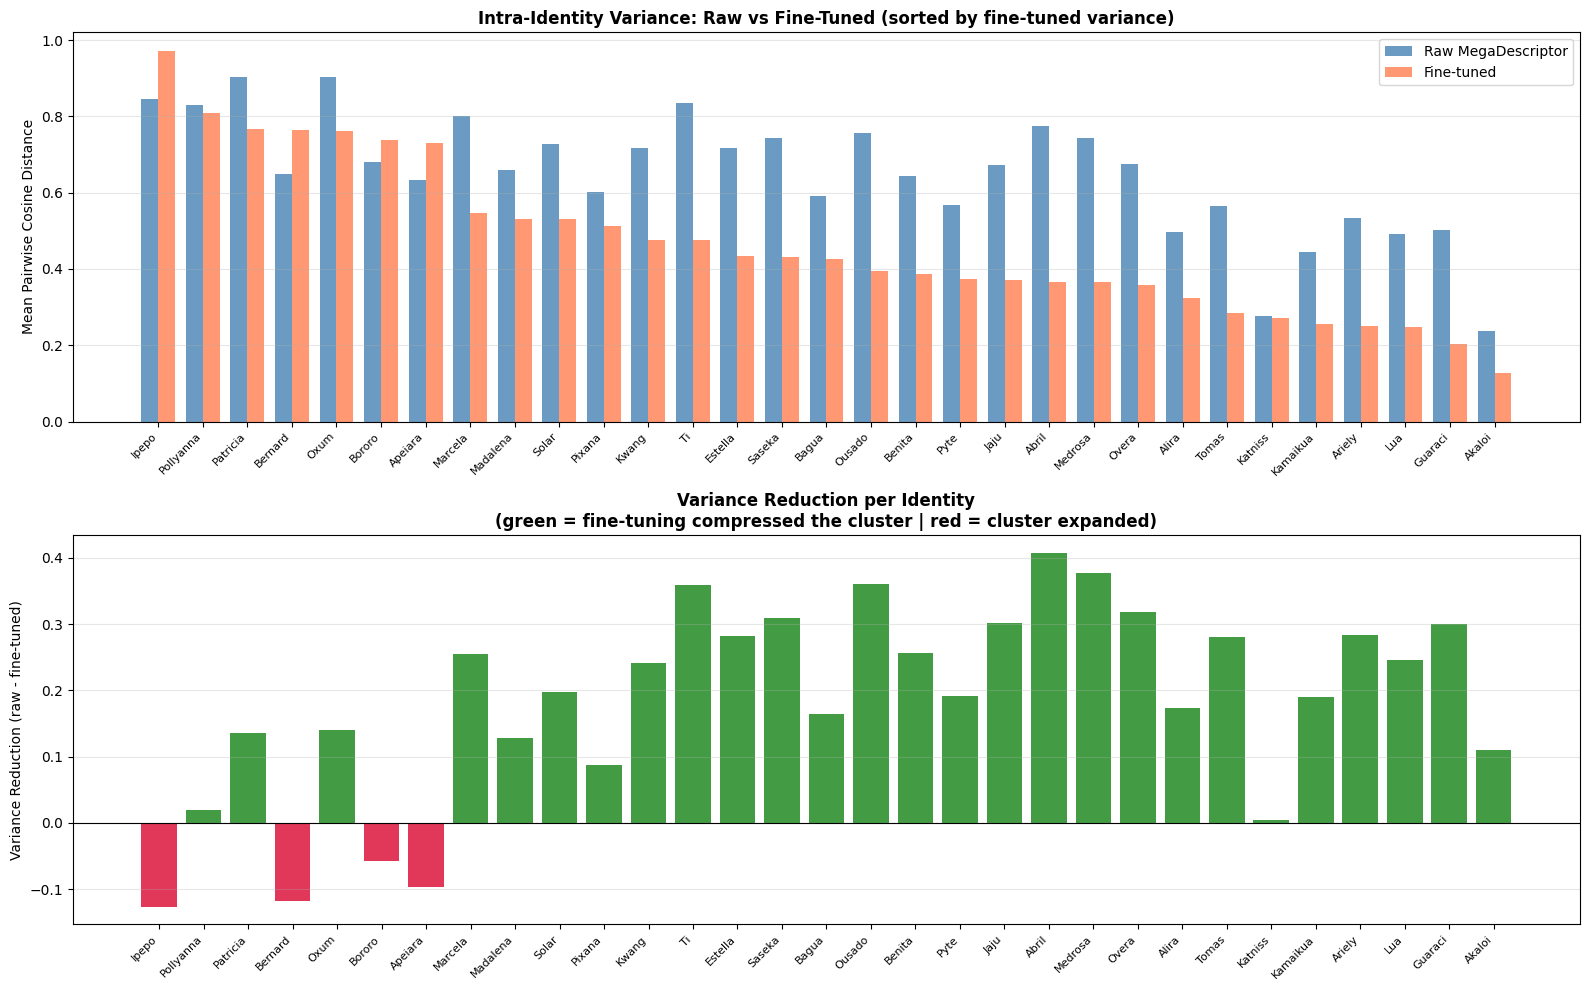

Largest reduction: 0.4076 (Abril)
Largest expansion: -0.1267 (Ipepo)


In [15]:
sort_idx  = np.argsort(var_ft_vals)[::-1]
s_ids     = [identities[i]    for i in sort_idx]
s_var_raw = [var_raw_vals[i]  for i in sort_idx]
s_var_ft  = [var_ft_vals[i]   for i in sort_idx]
s_var_red = [var_reduction[i] for i in sort_idx]

x = np.arange(len(s_ids)); w = 0.38
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].bar(x - w/2, s_var_raw, w, label='Raw MegaDescriptor', color='steelblue', alpha=0.8)
axes[0].bar(x + w/2, s_var_ft,  w, label='Fine-tuned',         color='coral',     alpha=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(s_ids, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Pairwise Cosine Distance')
axes[0].set_title('Intra-Identity Variance: Raw vs Fine-Tuned (sorted by fine-tuned variance)',
                   fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

colors = ['forestgreen' if v >= 0 else 'crimson' for v in s_var_red]
axes[1].bar(x, s_var_red, color=colors, alpha=0.85)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(s_ids, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Variance Reduction (raw - fine-tuned)')
axes[1].set_title('Variance Reduction per Identity\n'
                   '(green = fine-tuning compressed the cluster | red = cluster expanded)',
                   fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
wandb.log({'variance/bar_chart': wandb.Image(fig)})
plt.savefig(config['checkpoint_dir']/'variance_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Largest reduction: {var_reduction.max():.4f} ({identities[np.argmax(var_reduction)]})')
print(f'Largest expansion: {var_reduction.min():.4f} ({identities[np.argmin(var_reduction)]})')

## 10. Variance vs Per-Identity AP: Spearman Correlation

We expect **negative Spearman rho**: high-variance identities should have low AP.
Outliers from this trend reveal different failure modes:

- **Low variance + Low AP**: tight but misplaced cluster -- confused with another identity
- **High variance + High AP**: scattered but still distinctive

Spearman correlation (variance vs AP):
  Raw MegaDescriptor: rho=-0.8762  p=0.0000
  Fine-tuned:         rho=-0.9046  p=0.0000


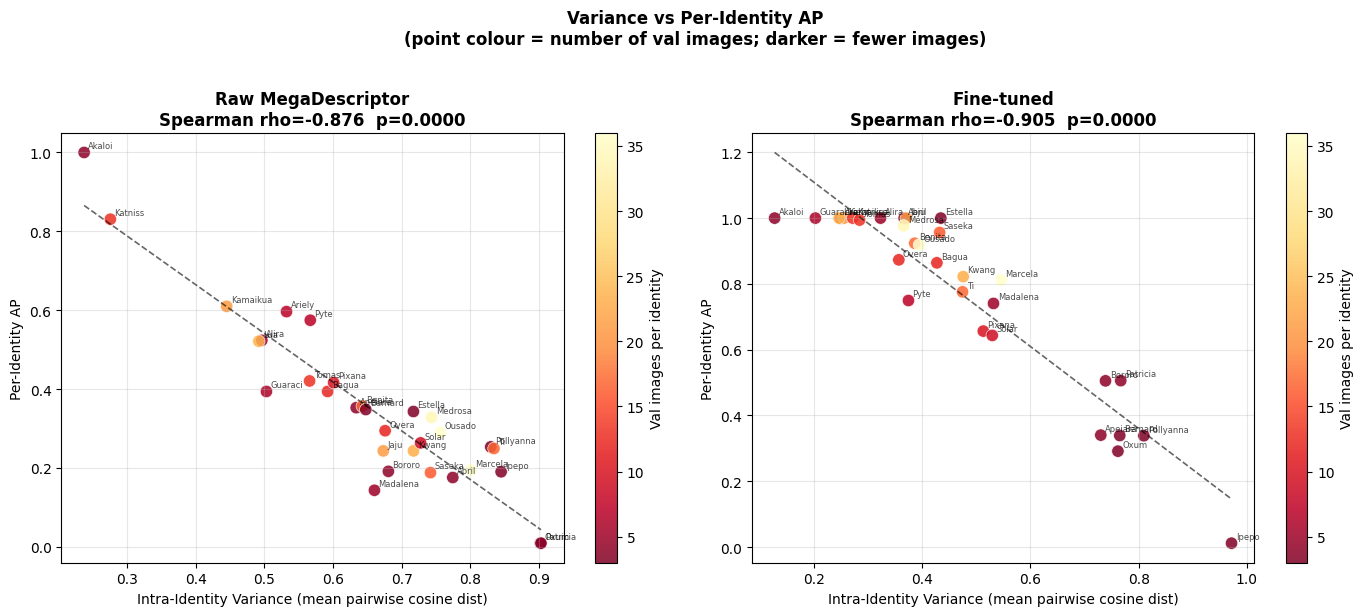

In [16]:
rho_raw, p_raw = stats.spearmanr(var_raw_vals, ap_raw_vals)
rho_ft,  p_ft  = stats.spearmanr(var_ft_vals,  ap_ft_vals)

print(f'Spearman correlation (variance vs AP):')
print(f'  Raw MegaDescriptor: rho={rho_raw:.4f}  p={p_raw:.4f}')
print(f'  Fine-tuned:         rho={rho_ft:.4f}  p={p_ft:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
counts = np.array([val_counts[i] for i in identities])

for ax, (var_v, ap_v, label, rho, p) in zip(axes, [
    (var_raw_vals, ap_raw_vals, 'Raw MegaDescriptor', rho_raw, p_raw),
    (var_ft_vals,  ap_ft_vals,  'Fine-tuned',         rho_ft,  p_ft),
]):
    sc = ax.scatter(var_v, ap_v, c=counts, cmap='YlOrRd_r',
                    s=80, alpha=0.85, edgecolors='white', linewidths=0.5)
    plt.colorbar(sc, ax=ax, label='Val images per identity')
    for i, name in enumerate(identities):
        ax.annotate(name, (var_v[i], ap_v[i]), fontsize=6, alpha=0.7,
                    xytext=(3,3), textcoords='offset points')
    z = np.polyfit(var_v, ap_v, 1)
    xfit = np.linspace(var_v.min(), var_v.max(), 100)
    ax.plot(xfit, np.polyval(z, xfit), 'k--', linewidth=1.2, alpha=0.6)
    ax.set_xlabel('Intra-Identity Variance (mean pairwise cosine dist)')
    ax.set_ylabel('Per-Identity AP')
    ax.set_title(f'{label}\nSpearman rho={rho:.3f}  p={p:.4f}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Variance vs Per-Identity AP\n'
             '(point colour = number of val images; darker = fewer images)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
wandb.log({'correlation/variance_vs_ap': wandb.Image(fig)})
plt.savefig(config['checkpoint_dir']/'variance_vs_ap.png', dpi=150, bbox_inches='tight')
plt.show()

wandb.log({'correlation/spearman_rho_raw': rho_raw, 'correlation/p_raw': p_raw,
           'correlation/spearman_rho_ft':  rho_ft,  'correlation/p_ft':  p_ft})

## 11. Outlier Quadrant Analysis

Split identities into four quadrants around the median variance and median AP:

| Quadrant | Variance | AP | Interpretation |
|---|---|---|---|
| **easy** | Low | High | Distinctive coat, tight cluster |
| **hard-scattered** | High | Low | Visually inconsistent, model confused |
| **surprising-hard** | Low | Low | Tight but wrong -- confused with another ID |
| **surprising-easy** | High | High | Scattered but still distinguishable |

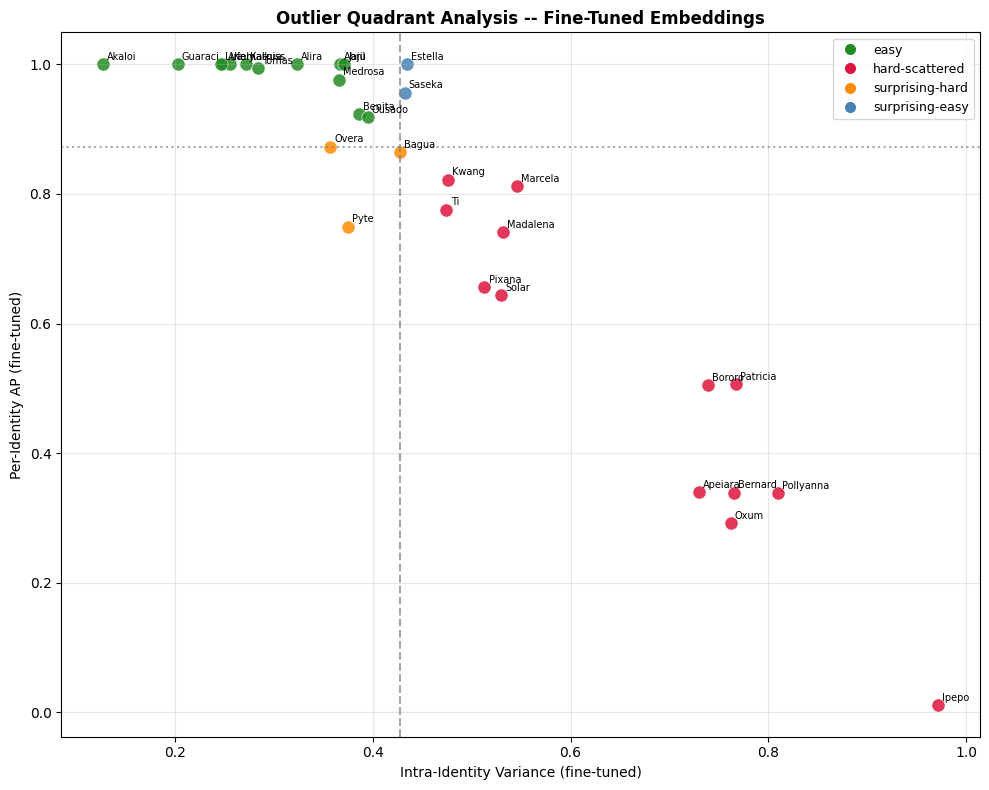

  easy                  : 13 identities -- ['Abril', 'Akaloi', 'Alira', 'Ariely', 'Benita', 'Guaraci', 'Jaju', 'Kamaikua', 'Katniss', 'Lua', 'Medrosa', 'Ousado', 'Tomas']
  hard-scattered        : 13 identities -- ['Apeiara', 'Bernard', 'Bororo', 'Ipepo', 'Kwang', 'Madalena', 'Marcela', 'Oxum', 'Patricia', 'Pixana', 'Pollyanna', 'Solar', 'Ti']
  surprising-hard       :  3 identities -- ['Bagua', 'Overa', 'Pyte']
  surprising-easy       :  2 identities -- ['Estella', 'Saseka']


In [17]:
med_var = np.median(var_ft_vals)
med_ap  = np.median(ap_ft_vals)

quadrants = {}
for i, identity in enumerate(identities):
    hi_var = var_ft_vals[i] > med_var
    hi_ap  = ap_ft_vals[i]  > med_ap
    if     hi_var and     hi_ap: q = 'surprising-easy'
    elif   hi_var and not hi_ap: q = 'hard-scattered'
    elif not hi_var and     hi_ap: q = 'easy'
    else:                          q = 'surprising-hard'
    quadrants[identity] = q

q_colors = {'easy': 'forestgreen', 'hard-scattered': 'crimson',
            'surprising-hard': 'darkorange', 'surprising-easy': 'steelblue'}

fig, ax = plt.subplots(figsize=(10, 8))
for identity in identities:
    i = identities.index(identity)
    ax.scatter(var_ft_vals[i], ap_ft_vals[i],
               color=q_colors[quadrants[identity]], s=90,
               alpha=0.85, edgecolors='white', linewidths=0.5)
    ax.annotate(identity, (var_ft_vals[i], ap_ft_vals[i]),
                fontsize=7, xytext=(3,3), textcoords='offset points')

ax.axvline(x=med_var, color='gray', linestyle='--', alpha=0.7, label=f'Median var={med_var:.3f}')
ax.axhline(y=med_ap,  color='gray', linestyle=':',  alpha=0.7, label=f'Median AP={med_ap:.3f}')
handles = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=c, markersize=9, label=l)
           for l, c in q_colors.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_xlabel('Intra-Identity Variance (fine-tuned)')
ax.set_ylabel('Per-Identity AP (fine-tuned)')
ax.set_title('Outlier Quadrant Analysis -- Fine-Tuned Embeddings', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
wandb.log({'correlation/quadrant_plot': wandb.Image(fig)})
plt.savefig(config['checkpoint_dir']/'quadrant_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

for qname in q_colors:
    members = [i for i, q in quadrants.items() if q == qname]
    print(f'  {qname:<22}: {len(members):2d} identities -- {members}')

## 12. Hard Pair Visualisation

For the **top 5 highest-variance identities**, find the most dissimilar image pair
within the identity (hardest pair) and the most similar pair (easiest pair).
Showing them side-by-side makes the failure mode concrete.

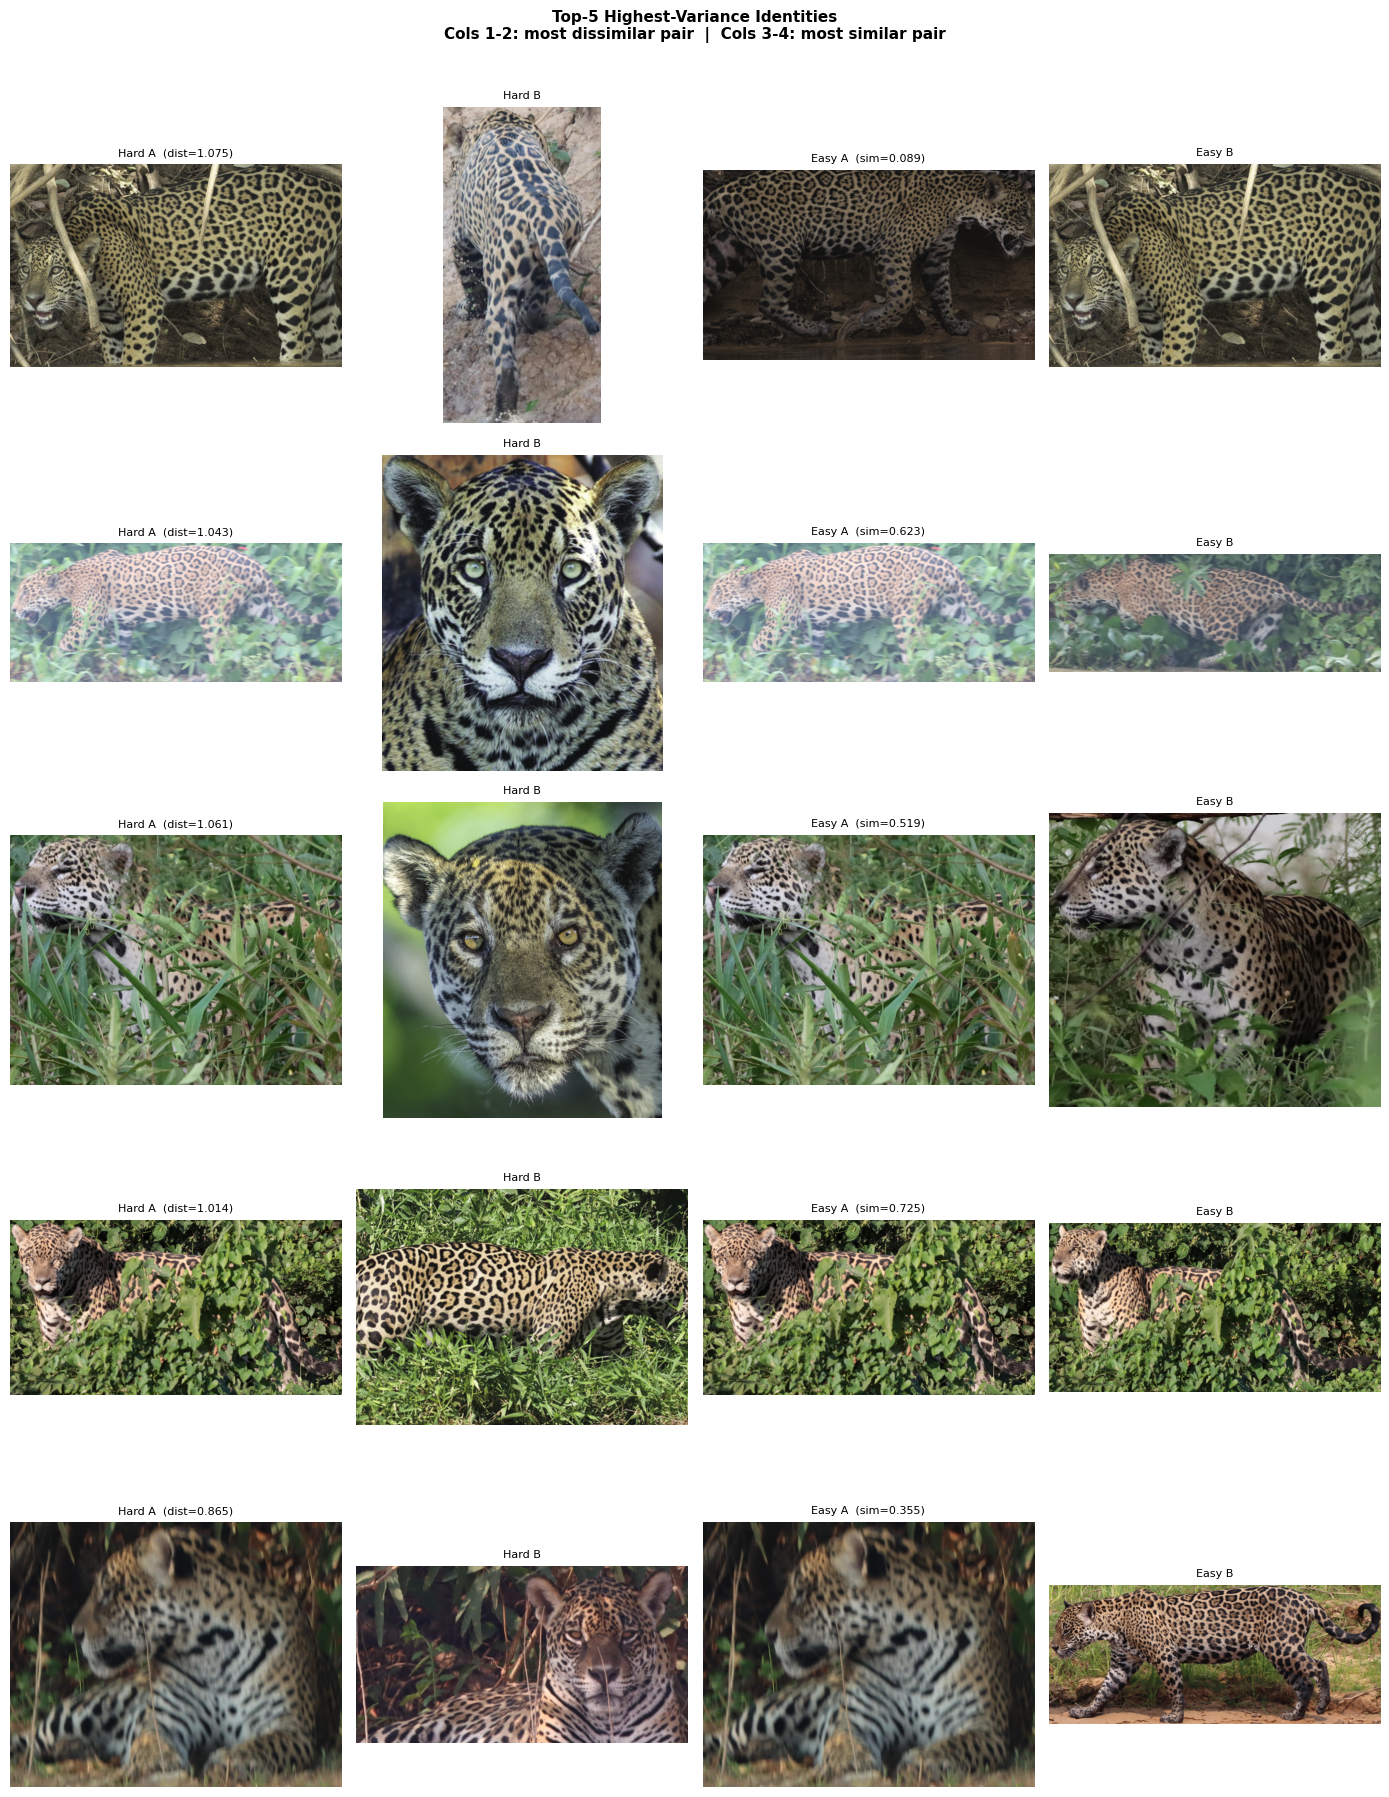

In [18]:
def find_extreme_pairs(embs_n, labels, identity):
    mask    = np.where(labels == identity)[0]
    vecs    = embs_n[mask]
    sim_mat = vecs @ vecs.T
    # Hardest pair: minimum similarity (off-diagonal)
    hard_mat = sim_mat.copy(); np.fill_diagonal(hard_mat,  1.0)
    easy_mat = sim_mat.copy(); np.fill_diagonal(easy_mat, -1.0)
    ha, hb = divmod(np.argmin(hard_mat), len(mask))
    ea, eb = divmod(np.argmax(easy_mat), len(mask))
    return (mask[ha], mask[hb], float(1.0 - sim_mat[ha, hb]),
            mask[ea], mask[eb], float(sim_mat[ea, eb]))


def load_image(path):
    try:    return Image.open(path).convert('RGB')
    except: return Image.new('RGB', (384, 384), (128, 128, 128))


top5_ids = [identities[i] for i in np.argsort(var_ft_vals)[::-1][:5]]

fig, axes = plt.subplots(5, 4, figsize=(14, 18))
for row, identity in enumerate(top5_ids):
    ha, hb, hdist, ea, eb, esim = find_extreme_pairs(ft_embs_n, val_labels_str, identity)

    for col, (path, subtitle) in enumerate([
        (val_paths[ha], f'Hard A  (dist={hdist:.3f})'),
        (val_paths[hb], 'Hard B'),
        (val_paths[ea], f'Easy A  (sim={esim:.3f})'),
        (val_paths[eb], 'Easy B'),
    ]):
        axes[row, col].imshow(load_image(path))
        axes[row, col].axis('off')
        axes[row, col].set_title(subtitle, fontsize=8)

    axes[row, 0].set_ylabel(
        f'{identity}\nvar={var_ft[identity]:.3f}  AP={ap_ft[identity]:.3f}\n'
        f'[{quadrants[identity]}]  n={val_counts[identity]}',
        fontsize=8, rotation=0, labelpad=90, va='center')

plt.suptitle('Top-5 Highest-Variance Identities\n'
             'Cols 1-2: most dissimilar pair  |  Cols 3-4: most similar pair',
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
wandb.log({'hard_pairs/top5': wandb.Image(fig)})
plt.savefig(config['checkpoint_dir']/'hard_pairs_top5.png', dpi=120, bbox_inches='tight')
plt.show()

## 13. Surprising-Hard Identities: Tight but Wrong Clusters

Low variance + low AP means the model is confidently placing all images from this
identity in the same region -- but that region overlaps with another identity's cluster.
We find the most frequent wrong top-1 retrieval to identify the confusion partner.

In [19]:
surprising_hard = [i for i, q in quadrants.items() if q == 'surprising-hard']
print(f'Surprising-hard identities ({len(surprising_hard)}): {surprising_hard}')

if surprising_hard:
    sim_all = ft_embs_n @ ft_embs_n.T
    np.fill_diagonal(sim_all, -1)
    print(f'\n  {"Identity":<20}  {"var":>6}  {"AP":>6}  Most confused with    Confusion rate')
    print('  ' + '-'*70)
    for identity in surprising_hard:
        q_idxs = np.where(val_labels_str == identity)[0]
        confused_with = []
        for q_idx in q_idxs:
            top1 = np.argmax(sim_all[q_idx])
            if val_labels_str[top1] != identity:
                confused_with.append(val_labels_str[top1])
        if confused_with:
            partner = max(set(confused_with), key=confused_with.count)
            rate    = confused_with.count(partner) / len(q_idxs)
        else:
            partner = 'none'; rate = 0.0
        i = identities.index(identity)
        print(f'  {identity:<20}  {var_ft_vals[i]:.4f}  {ap_ft_vals[i]:.4f}  '
              f'{partner:<20}  {rate:.1%}')
else:
    print('No surprising-hard identities found (all quadrants have intuitive results).')

Surprising-hard identities (3): ['Bagua', 'Overa', 'Pyte']

  Identity                 var      AP  Most confused with    Confusion rate
  ----------------------------------------------------------------------
  Bagua                 0.4273  0.8641  Madalena              8.3%
  Overa                 0.3569  0.8732  Saseka                8.3%
  Pyte                  0.3748  0.7496  Ti                    14.3%


## 14. Results Summary Table

In [20]:
print('='*80)
print('EXPERIMENT 9: INTRA-IDENTITY VARIANCE -- RESULTS SUMMARY')
print('='*80)
print(f'  Overall mAP: Raw={map_raw:.4f}  Fine-tuned={map_ft:.4f}  Delta={map_ft-map_raw:+.4f}')
print(f'  Mean variance: Raw={var_raw_vals.mean():.4f}  Fine-tuned={var_ft_vals.mean():.4f}')
print(f'  Spearman rho (var vs AP):')
print(f'    Raw:        rho={rho_raw:.4f}  p={p_raw:.4f}')
print(f'    Fine-tuned: rho={rho_ft:.4f}  p={p_ft:.4f}')
print(f'  Quadrant breakdown:')
for qname in ['easy','hard-scattered','surprising-hard','surprising-easy']:
    members = [i for i, q in quadrants.items() if q == qname]
    print(f'    {qname:<22}: {len(members):2d} identities')
print('='*80)

rows = [{
    'identity':      identity,
    'val_count':     int(val_counts[identity]),
    'var_raw':       round(float(var_raw_vals[i]), 4),
    'var_ft':        round(float(var_ft_vals[i]),  4),
    'var_reduction': round(float(var_reduction[i]),4),
    'ap_raw':        round(float(ap_raw_vals[i]),  4),
    'ap_ft':         round(float(ap_ft_vals[i]),   4),
    'quadrant':      quadrants[identity],
} for i, identity in enumerate(identities)]

summary_df = pd.DataFrame(rows).sort_values('var_ft', ascending=False)
print(summary_df.to_string(index=False))

wandb.log({
    'results/map_raw':           map_raw,
    'results/map_ft':            map_ft,
    'results/mean_var_raw':      float(var_raw_vals.mean()),
    'results/mean_var_ft':       float(var_ft_vals.mean()),
    'results/spearman_rho_ft':   rho_ft,
    'results/n_hard_scattered':  sum(1 for q in quadrants.values() if q=='hard-scattered'),
    'results/n_surprising_hard': sum(1 for q in quadrants.values() if q=='surprising-hard'),
    'per_identity/summary_table': wandb.Table(dataframe=summary_df),
})
print('\nSummary table logged to W&B')

EXPERIMENT 9: INTRA-IDENTITY VARIANCE -- RESULTS SUMMARY
  Overall mAP: Raw=0.3531  Fine-tuned=0.7755  Delta=+0.4224
  Mean variance: Raw=0.6521  Fine-tuned=0.4673
  Spearman rho (var vs AP):
    Raw:        rho=-0.8762  p=0.0000
    Fine-tuned: rho=-0.9046  p=0.0000
  Quadrant breakdown:
    easy                  : 13 identities
    hard-scattered        : 13 identities
    surprising-hard       :  3 identities
    surprising-easy       :  2 identities
 identity  val_count  var_raw  var_ft  var_reduction  ap_raw  ap_ft        quadrant
    Ipepo          3   0.8449  0.9716        -0.1267  0.1901 0.0119  hard-scattered
Pollyanna          3   0.8297  0.8097         0.0201  0.2532 0.3385  hard-scattered
 Patricia          4   0.9030  0.7669         0.1360  0.0090 0.5060  hard-scattered
  Bernard          3   0.6477  0.7651        -0.1174  0.3479 0.3391  hard-scattered
     Oxum          3   0.9021  0.7618         0.1404  0.0091 0.2915  hard-scattered
   Bororo          4   0.6806  0.7388 

In [21]:
wandb.finish()
print('W&B run completed.')

checkpoint/epoch,▁
checkpoint/val_map,▁
correlation/p_ft,▁
correlation/p_raw,▁
correlation/spearman_rho_ft,▁
correlation/spearman_rho_raw,▁
num_identities,▁
results/map_ft,▁
results/map_raw,▁
results/mean_var_ft,▁
+13,...


W&B run completed.
